In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
file_path = 'data/steam_games.csv'
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
seed = 10
#print(f"stopwords {list(stop_words)[:100]}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Para o início do trabalho de agrupamento, utilizamos uma amostra de 15000 linhas do nosso conjunto de dados, que representa uma quantidade significativa do total, visando reduzir o uso dos recursos do computador e diminuir o tempo de execução.

In [3]:
def read_dataset(file_path):

    if not os.path.exists(file_path):
        print("ERRO: Arquivo de dados não encontrado!")
        return None

    df_complete = pd.read_csv(file_path)
    df_sample = df_complete.sample(n = 15000, random_state = seed)
    return df_sample

Em seguida realizamos a etapa de processamento, removendo as palavras, símbolos e números que não são relevantes para a análise. Palavras como "game" e "play" que aparecem em muitos grupos e não carregam nenhum tipo de informação sobre os itens.

In [4]:
def clean_text(text):
    porter = PorterStemmer()
    text = str(text)
    text = re.sub(r'\bwww\.', ' ', text)
    text = re.sub(r'\.(com|br)\b', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'http', ' ', text)
    text = re.sub(r'player', ' ', text)
    text = re.sub(r'play', ' ', text)
    text = re.sub(r'game', ' ', text)
    text = re.sub(r'gamer', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens_clean = [word for word in tokens if word not in stop_words]
    tokens_stemmed=[porter.stem(word) for word in tokens_clean]
    return " ".join(tokens_stemmed)

In [5]:
df_bruto = read_dataset(file_path)

if df_bruto is not None:

    # Limpando o arquivo, selecionando colunas que podem ser utilizadas
    important = [
        'appid', 'name', 'genres', 'description', 'short_description'
    ]
    df = df_bruto[important].copy()
    display(df.head())

,appid,name,genres,description,short_description
19741,782610,Tank 51,Action;Adventure;Casual;Indie,Tank 51 is an increasingly difficult retro sty...,Tank 51 is an increasingly difficult retro sty...
9032,466910,Worm.is: The Game,Casual;Free to Play,** From the creators of Mitos.is: The Game (82...,Smash worms or slither trying! Warning: Incred...
4254,334960,Cell HD: emergence,Action;Indie;Simulation,Against the &quot;smart germs&quot; of tomorro...,Based on a 3D version of mathematician John Co...
7065,410120,AGON - The Mysterious Codex (Trilogy),Adventure,AGON - The Mysterious Codex is a trilogy featu...,Professor Hunt embarks on an adventure journey...
25168,960320,Ego Hearts,Free to Play;Indie,<strong>***USE GAMEPAD FOR BEST EXPERIENCE***<...,Ego Hearts is a small interactive reflection a...


In [6]:
#aplicando a função de limpeza em cada um dos elementos do conjunto
game_descriptions_clean = df['description'].apply(clean_text)


Nesta etapa, calculamos o TF-IDF das palavras para cada jogo para poder computar a dissimilaridade entre os elementos posteriormente.
Os parâmetros max_df e min_df são utilizados para remover palavras que aparecem com frequência na descrição de vários jogos e que, consequente, não carregam informação significativa sobre os itens.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.8,min_df=10)
tfidf_matrix = vectorizer.fit_transform(game_descriptions_clean)
print(f"Formato da matriz: {tfidf_matrix.shape}")

Formato da matriz: (15000, 7756)


Em seguida aplicamos uma versão do PCA que funciona para matrizes esparsas de forma eficiente, o LSA. Esta versão não centraliza os dados antes de realizar a decomposição dos valores singulares(SVD) evitando que a matriz de distância fique muito densa. Além disso é passado o parâmetro Normalizer(copy=False) normaliza e modfica a mesma matriz sem criar uma cópia.
O trecho de código abaixo foi adaptado da documentação da scikit-learn: https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html

In [8]:

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline


#trecho de código de https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
lsa_pipeline = make_pipeline(TruncatedSVD(n_components=2000, random_state=seed), 
                              Normalizer(copy=False))
lsa=lsa_pipeline[0]

#Aplicando o LSA para o conjunto de dados
final_matrix = lsa_pipeline.fit_transform(tfidf_matrix)


print(f"original: {tfidf_matrix.shape}")
print(f"reduzido: {final_matrix.shape}")

original: (15000, 7756)
reduzido: (15000, 2000)


Abaixo plotamos o gráfico de quanto dos dados foram preservados após a aplicação do PCA. Assim, foi possível perceber que aproximadamente 80% da informação foi preservada mesmo após a redução do número de colunas, indicando uma boa escolha na quantidade de features do nosso modelo.

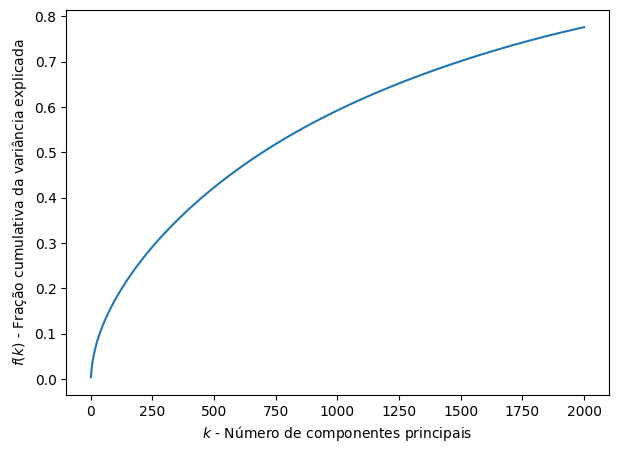

In [9]:
fig = plt.figure(figsize=(7, 5))
plt.plot([i for i in range(1, lsa.n_components + 1)], np.cumsum(lsa.explained_variance_ratio_))
plt.xlabel(r'$k$ - Número de componentes principais')
plt.ylabel(r'$f(k)$ - Fração cumulativa da variância explicada');

Para o próximo passo aplicamos o K-means para um número determinado de clusters e utilizamos as métricas vistas em aula (inércia e silhueta),além de outras escolhidas a partir da scikit-learn (Calinski e davies), para verificar os valores de k que seriam mais adequados para a nossa análise. Escolhemos então k=16, por ser um valor que representa bons valores para os coefiecientes de silhueta, calinski e bouldin simultaneamente. 

In [10]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

#### agrupamento K-means ####

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score
#plota distribuição de dados de acordo com o valor do coeficiente de silhueta

def visualize_metricas_plot(k_init,k_final):
    range_cluster=range(k_init, k_final)

    inertia = []
    silhouette = []
    calinski = []
    davies = []
    
    for n_clusters in range_cluster:
        # Create a subplot with 1 row and 2 columns
        # fig, (ax1, ax2) = plt.subplots(1, 2)
        # fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        # ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        # ax1.set_ylim([0, len(final_matrix) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, random_state=seed,init='k-means++', n_init = 10)
        cluster_labels = clusterer.fit_predict(final_matrix)

        # metrica do cotovelo
        inertia.append(clusterer.inertia_)
        
        silhouette_avg = silhouette_score(final_matrix, cluster_labels)
        silhouette.append(silhouette_avg)
        
        score_ch = calinski_harabasz_score(final_matrix, cluster_labels)
        calinski.append(score_ch)
        
        score_db = davies_bouldin_score(final_matrix, cluster_labels)
        davies.append(score_db)

        print(f"k={n_clusters} |Sillhouette: {silhouette_avg:.6f} | CH: {score_ch:.2f} | DB: {score_db:.2f}")

        # Compute the silhouette scores for each sample
        # sample_silhouette_values = silhouette_samples(final_matrix, cluster_labels)

        # y_lower = 10
        # for i in range(n_clusters):
        #     # Aggregate the silhouette scores for samples belonging to
        #     # cluster i, and sort them
        #     ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        #     ith_cluster_silhouette_values.sort()

        #     size_cluster_i = ith_cluster_silhouette_values.shape[0]
        #     y_upper = y_lower + size_cluster_i

        #     color = cm.nipy_spectral(float(i) / n_clusters)
        #     ax1.fill_betweenx(
        #         np.arange(y_lower, y_upper),
        #         0,
        #         ith_cluster_silhouette_values,
        #         facecolor=color,
        #         edgecolor=color,
        #         alpha=0.7,
        #     )

        #     # Label the silhouette plots with their cluster numbers at the middle
        #     ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        #     # Compute the new y_lower for next plot
        #     y_lower = y_upper + 10  # 10 for the 0 samples

        # ax1.set_title("The silhouette plot for the various clusters.")
        # ax1.set_xlabel("The silhouette coefficient values")
        # ax1.set_ylabel("Cluster label")

        # # The vertical line for average silhouette score of all the values
        # ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        # ax1.set_yticks([])  # Clear the yaxis labels / ticks
        # ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # # 2nd Plot showing the actual clusters formed
        # colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        # ax2.scatter(
        #     final_matrix[:, 0], final_matrix[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        # )

        # # Labeling the clusters
        # centers = clusterer.cluster_centers_
        # # Draw white circles at cluster centers
        # ax2.scatter(
        #     centers[:, 0],
        #     centers[:, 1],
        #     marker="o",
        #     c="white",
        #     alpha=1,
        #     s=200,
        #     edgecolor="k",
        # )

        # for i, c in enumerate(centers):
        #     ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        # ax2.set_title("The visualization of the clustered data.")
        # ax2.set_xlabel("Feature space for the 1st feature")
        # ax2.set_ylabel("Feature space for the 2nd feature")

        # plt.suptitle(
        #     "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        #     % n_clusters,
        #     fontsize=14,
        #     fontweight="bold",
        # )

    # Plotando os 3 gráficos lado a lado
    fig, axes = plt.subplots(4, 1, figsize=(10, 15))
    
    # Gráfico 1: Elbow
    axes[0].plot(range_cluster, inertia, marker='o')
    axes[0].set_title('Cotovelo')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inércia ')

    # Gráfico 1: silhouette
    axes[1].plot(range_cluster, silhouette, marker='o')
    axes[1].set_title('silhouette')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('silhouette (Maior é melhor)')
        
    # Gráfico 3: Calinski-Harabasz
    axes[2].plot(range_cluster, calinski, marker='o', color='orange')
    axes[2].set_title('Calinski-Harabasz Score')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Score (Maior é melhor)')
    
    # Gráfico 4: Davies-Bouldin
    axes[3].plot(range_cluster, davies, marker='o', color='green')
    axes[3].set_title('Davies-Bouldin Index')
    axes[3].set_xlabel('k')
    axes[3].set_ylabel('Score (Menor é melhor)')
    
    plt.tight_layout()
    plt.show()

k=10 |Sillhouette: 0.006649 | CH: 55.05 | DB: 8.67
k=11 |Sillhouette: 0.007687 | CH: 52.70 | DB: 8.55
k=12 |Sillhouette: 0.007993 | CH: 50.72 | DB: 8.06
k=13 |Sillhouette: 0.007842 | CH: 49.33 | DB: 8.05
k=14 |Sillhouette: 0.008206 | CH: 47.93 | DB: 7.93
k=15 |Sillhouette: 0.009673 | CH: 46.53 | DB: 7.75
k=16 |Sillhouette: 0.008748 | CH: 44.46 | DB: 7.88
k=17 |Sillhouette: 0.009543 | CH: 43.61 | DB: 7.59
k=18 |Sillhouette: 0.009828 | CH: 42.93 | DB: 7.26
k=19 |Sillhouette: 0.009700 | CH: 41.35 | DB: 7.28
k=20 |Sillhouette: 0.010742 | CH: 41.02 | DB: 7.39
k=21 |Sillhouette: 0.010747 | CH: 40.25 | DB: 7.11
k=22 |Sillhouette: 0.010852 | CH: 38.97 | DB: 6.99


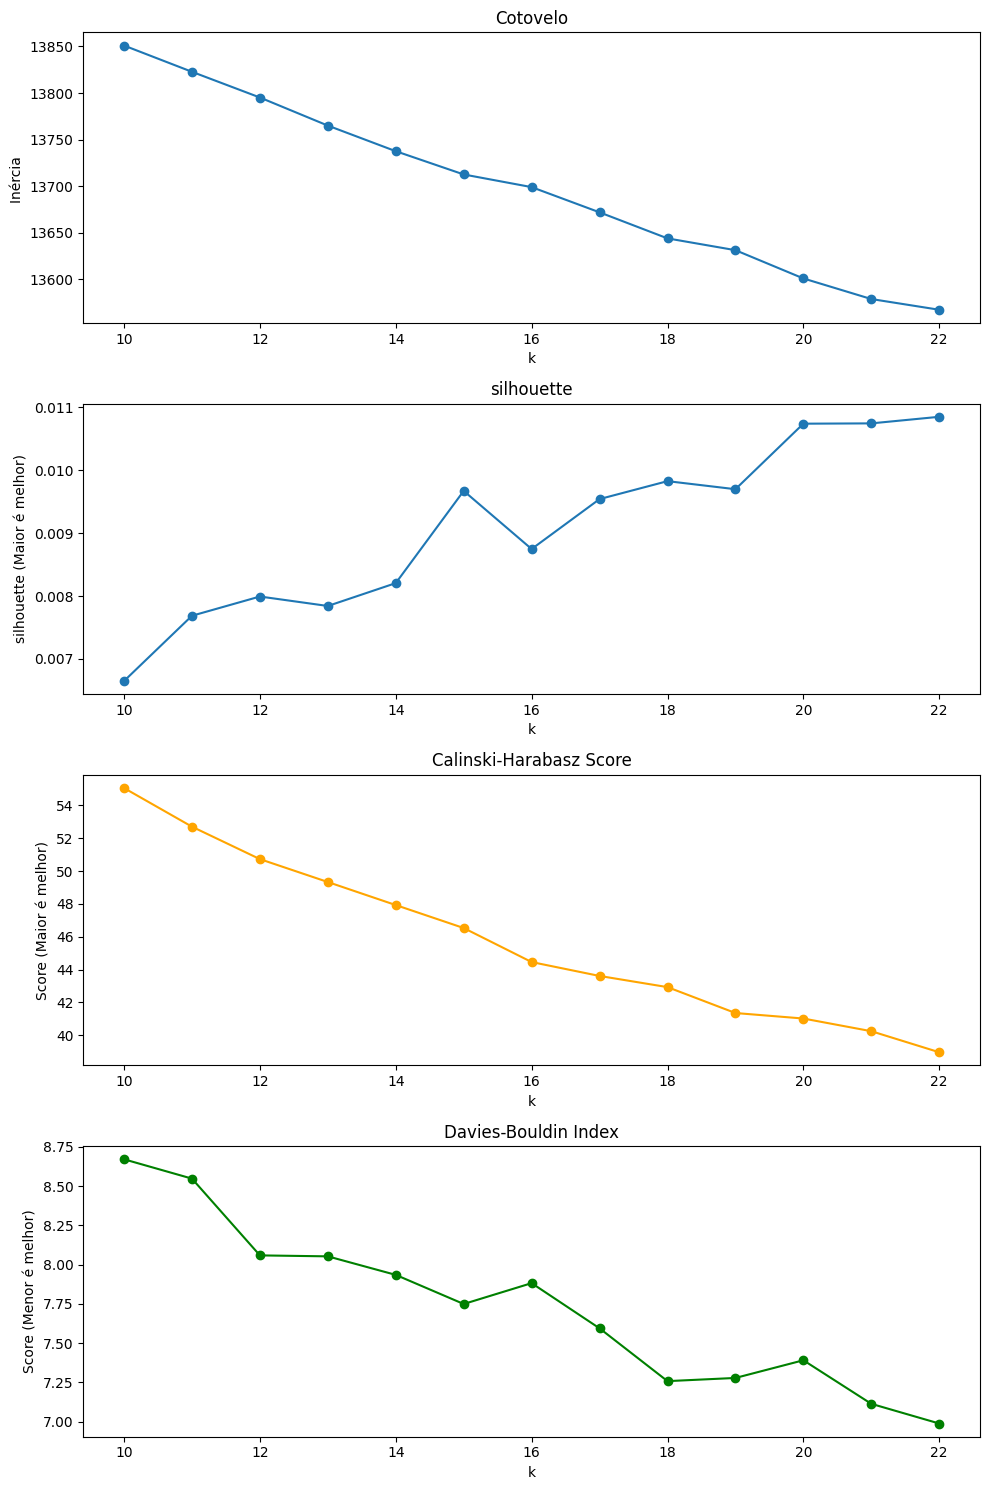

In [11]:

visualize_metricas_plot(10,23)

Agora, precisamos verificar se o conjunto de palavras de cada cluster fazem parte de um mesmo contexto. Por exemplo, esperamos que um jogo do gênero "Corrida" contenha as palavras como: "car","race","velocity" entre outras que se encaixam nesse conjunto. Para isso, verificamos as top 10 palavras que possuem maior peso dentro de cada cluster.

In [15]:
#Imprime as 10 palavras de maiores peso para cada cluster
#https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
kmeans=KMeans(n_clusters=16, random_state=seed,init='k-means++', n_init = 10)
kmeans.fit_predict(final_matrix)
original_space_centroids = lsa.inverse_transform(kmeans.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(0,16):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()
    

Cluster 0: planet alien space earth robot human enemi weapon new mission 
Cluster 1: ship space enemi pirat fleet crew upgrad weapon galaxi battl 
Cluster 2: mode enemi weapon multi fight onlin control team friend new 
Cluster 3: race car track drive mode vehicl racer speed driver drift 
Cluster 4: stori girl end charact novel life choic love one quot 
Cluster 5: get time use world new featur game make level one 
Cluster 6: zombi surviv weapon kill undead mode hord survivor level infect 
Cluster 7: dungeon monster gener item hero explor level charact enemi adventur 
Cluster 8: level platform challeng puzzl get control differ collect jump featur 
Cluster 9: vr experi virtual vive realiti htc oculu room control world 
Cluster 10: find adventur mysteri puzzl hidden explor solv world dark stori 
Cluster 11: war unit battl command campaign enemi tactic strategi armi mission 
Cluster 12: puzzl solv level challeng logic color relax featur time new 
Cluster 13: world hero magic power battl ene

Nesse sentido, conseguimos encontrar alguns clusters que fazem sentido. O cluster 3, por exemplo, indica o gênero "racing", o qual é um gênero real do nosso conjunto de dados. Porém, clusters como o de número 6 indicaria uma espécie de jogo do gênero "zumbi" ou "pós-apolíptico", que não está explicitamente no conjunto de dados.

Para efeito de comparação, agruparemos agora o conjunto de jogos utilizando o agrupamento aglomerativo da scikit-learn. Os critérios de avaliação de agrupamento serão os mesmos para o k-means.

In [ ]:
####Agrupamento aglomerativo####

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score

range_cluster=range(20, 25)

inertia = []
silhouette = []
calinski = []
davies = []
print("Agrupamento Aglomerativo")
for n_clusters in range_cluster:
    
    clusterer = AgglomerativeClustering(n_clusters=n_clusters,linkage='ward',metric='euclidean')
    cluster_labels = clusterer.fit_predict(final_matrix)

    silhouette_avg = silhouette_score(final_matrix, cluster_labels)

    silhouette_avg = silhouette_score(final_matrix, cluster_labels)
    silhouette.append(silhouette_avg)
    
    score_ch = calinski_harabasz_score(final_matrix, cluster_labels)
    calinski.append(score_ch)
    
    score_db = davies_bouldin_score(final_matrix, cluster_labels)
    davies.append(score_db)

    print(f"k={n_clusters} |Sillhouette: {silhouette_avg:.6f} | CH: {score_ch:.2f} | DB: {score_db:.2f}")


fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Gráfico 1: silhouette
axes[0].plot(range_cluster, silhouette, marker='o')
axes[0].set_title('silhouette')
axes[0].set_xlabel('k')
axes[0].set_ylabel('silhouette (Maior é melhor)')
    
# Gráfico 3: Calinski-Harabasz
axes[1].plot(range_cluster, calinski, marker='o', color='orange')
axes[1].set_title('Calinski-Harabasz Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score (Maior é melhor)')

# Gráfico 4: Davies-Bouldin
axes[2].plot(range_cluster, davies, marker='o', color='green')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score (Menor é melhor)')

plt.tight_layout()
plt.show()

Agrupamento Aglomerativo


/* Fazer aq a analise de como as metricas ficaram melhores ou piores para o aglomerativo.*/

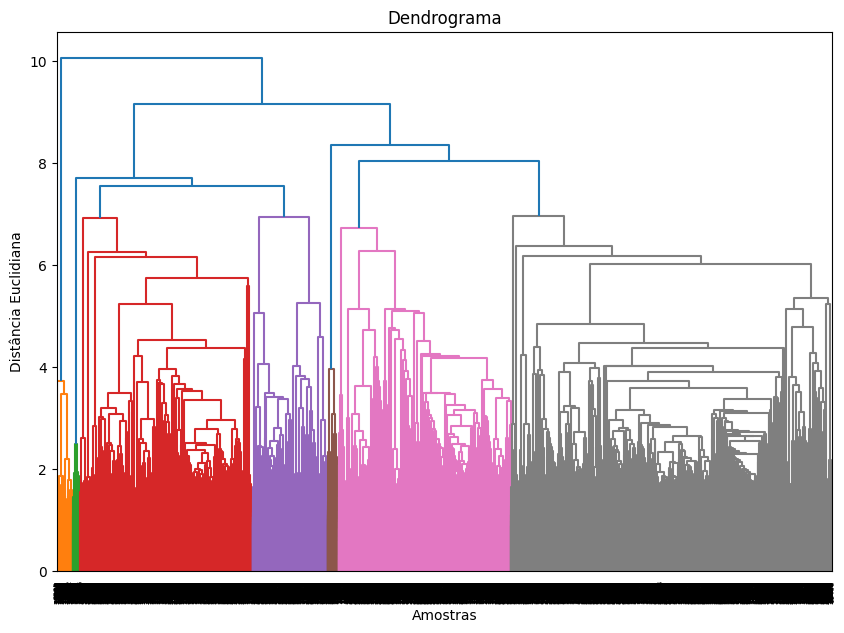

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(final_matrix, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title("Dendrograma")
plt.xlabel("Amostras")
plt.ylabel("Distância Euclidiana")
plt.show()

Visualmente o dendograma nos permite dizer com certeza que os elementos agrupados não apresentam grupos separados em ilhas mas sim um conjunto de grupos que se sobrepõem e apresentam uma certa hierarquia.

In [17]:
kmeans_final = KMeans(n_clusters=16, random_state=seed, init='k-means++', n_init=10)
labels = kmeans_final.fit_predict(final_matrix)
df['cluster'] = labels
display(df.head())

,appid,name,genres,description,short_description,cluster
19741,782610,Tank 51,Action;Adventure;Casual;Indie,Tank 51 is an increasingly difficult retro sty...,Tank 51 is an increasingly difficult retro sty...,0
9032,466910,Worm.is: The Game,Casual;Free to Play,** From the creators of Mitos.is: The Game (82...,Smash worms or slither trying! Warning: Incred...,5
4254,334960,Cell HD: emergence,Action;Indie;Simulation,Against the &quot;smart germs&quot; of tomorro...,Based on a 3D version of mathematician John Co...,15
7065,410120,AGON - The Mysterious Codex (Trilogy),Adventure,AGON - The Mysterious Codex is a trilogy featu...,Professor Hunt embarks on an adventure journey...,10
25168,960320,Ego Hearts,Free to Play;Indie,<strong>***USE GAMEPAD FOR BEST EXPERIENCE***<...,Ego Hearts is a small interactive reflection a...,5


In [18]:
generos_separados = df['genres'].fillna('').str.split(';').explode()
generos_separados = generos_separados.str.strip()
generos_separados = generos_separados[generos_separados != '']
lista_generos = generos_separados.unique()
print(lista_generos)

['Action' 'Adventure' 'Casual' 'Indie' 'Free to Play' 'Simulation' 'RPG'
 'Strategy' 'Sports' 'Animation & Modeling' 'Utilities' 'Video Production'
 'Early Access' 'Racing' 'Game Development' 'Massively Multiplayer'
 'Violent' 'Design & Illustration' 'Photo Editing' 'Audio Production'
 'Education' 'Software Training' 'Web Publishing' 'Accounting'
 'Documentary' 'Tutorial']


Para fazer a análise dos resultados, removemos alguns dos gêneros dos jogos, como por exemplo "Action", que aparecem em todos os clusters, portanto, não trazem informação relevante.

In [24]:
df_analise = df[['genres', 'cluster']].copy()
df_analise['genres'] = df_analise['genres'].fillna('').str.split(';')
trashlist = ['Indie', 'Casual', 'Early Access', 'Free to Play','Action']
df_exploded = df_analise.explode('genres')
df_filtered = df_exploded[~df_exploded['genres'].isin(trashlist)]
print(df_filtered)

           genres  cluster
19741   Adventure        0
4254   Simulation       15
7065    Adventure       10
15747   Adventure        5
7042    Adventure       14
...           ...      ...
6416          RPG       13
19852    Strategy        0
7638      Violent        4
7638    Adventure        4
7638          RPG        4

[16184 rows x 2 columns]


In [20]:
tab_final = pd.crosstab(df_filtered['cluster'], df_filtered['genres'])
display(tab_final.head())

genres,Accounting,Adventure,Animation & Modeling,Audio Production,Design & Illustration,Documentary,Education,Game Development,Massively Multiplayer,Photo Editing,...,Racing,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
cluster,,,,,,,,,,,,,,,,,,,,,
0,0,212,0,0,0,0,1,0,7,0,...,5,96,0,5,135,0,0,0,16,0
1,0,105,0,0,0,0,0,0,20,0,...,7,101,0,5,137,0,0,0,4,0
2,0,262,2,0,2,0,2,1,67,0,...,64,158,1,191,211,0,2,1,70,1
3,0,24,0,0,0,0,0,0,8,0,...,283,134,0,122,15,0,1,0,2,0
4,0,633,2,2,1,0,1,0,3,0,...,3,213,1,6,68,0,4,3,43,1


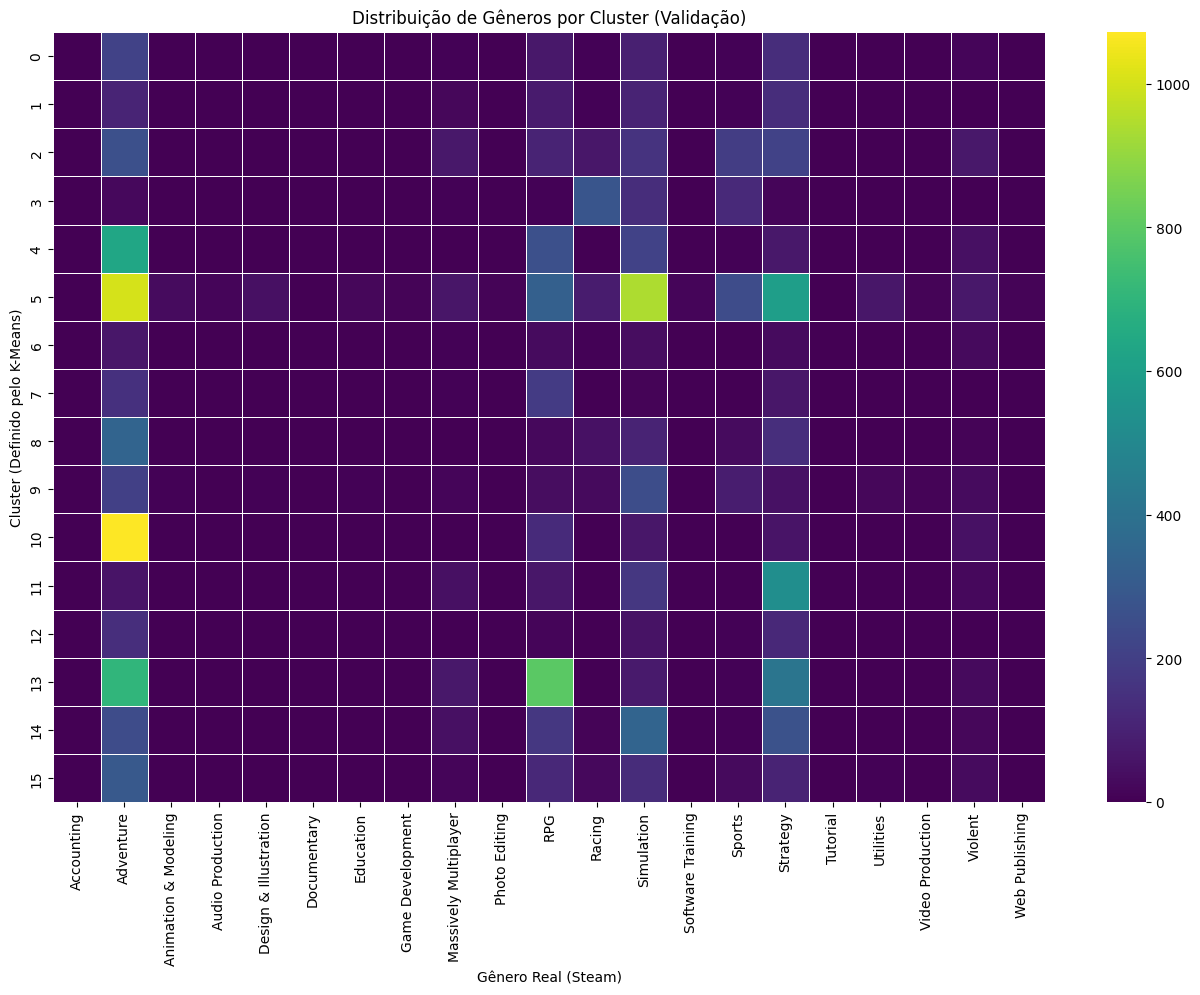

In [21]:
plt.figure(figsize=(16, 10))

sns.heatmap(tab_final, annot=False, cmap='viridis', linewidths=.5)

plt.title("Distribuição de Gêneros por Cluster (Validação)")
plt.ylabel("Cluster (Definido pelo K-Means)")
plt.xlabel("Gênero Real (Steam)")
plt.show()

Abaixo, na primeira célula temos a quantidade de jogos de acordo com o gênero para cada cluster definido. Em seguida verificamos novamente as palavras mais influentes de cada cluster para efeito de comparação visual.

In [22]:
for i in range(tab_final.shape[0]):
    print(f"\nCluster {i}:")
    # Pega os 3 maiores valores da linha e seus nomes
    top_genres = tab_final.iloc[i].nlargest(5) 
    for genero, qtd in top_genres.items():
        print(f"  - {genero}: {qtd} jogos")


Cluster 0:
  - Adventure: 212 jogos
  - Strategy: 135 jogos
  - Simulation: 96 jogos
  - RPG: 70 jogos
  - Violent: 16 jogos

Cluster 1:
  - Strategy: 137 jogos
  - Adventure: 105 jogos
  - Simulation: 101 jogos
  - RPG: 79 jogos
  - Massively Multiplayer: 20 jogos

Cluster 2:
  - Adventure: 262 jogos
  - Strategy: 211 jogos
  - Sports: 191 jogos
  - Simulation: 158 jogos
  - RPG: 102 jogos

Cluster 3:
  - Racing: 283 jogos
  - Simulation: 134 jogos
  - Sports: 122 jogos
  - Adventure: 24 jogos
  - Strategy: 15 jogos

Cluster 4:
  - Adventure: 633 jogos
  - RPG: 260 jogos
  - Simulation: 213 jogos
  - Strategy: 68 jogos
  - Violent: 43 jogos

Cluster 5:
  - Adventure: 1004 jogos
  - Simulation: 941 jogos
  - Strategy: 598 jogos
  - RPG: 325 jogos
  - Sports: 245 jogos

Cluster 6:
  - Adventure: 65 jogos
  - Simulation: 35 jogos
  - RPG: 30 jogos
  - Strategy: 30 jogos
  - Violent: 28 jogos

Cluster 7:
  - RPG: 187 jogos
  - Adventure: 148 jogos
  - Strategy: 66 jogos
  - Simulation: 1

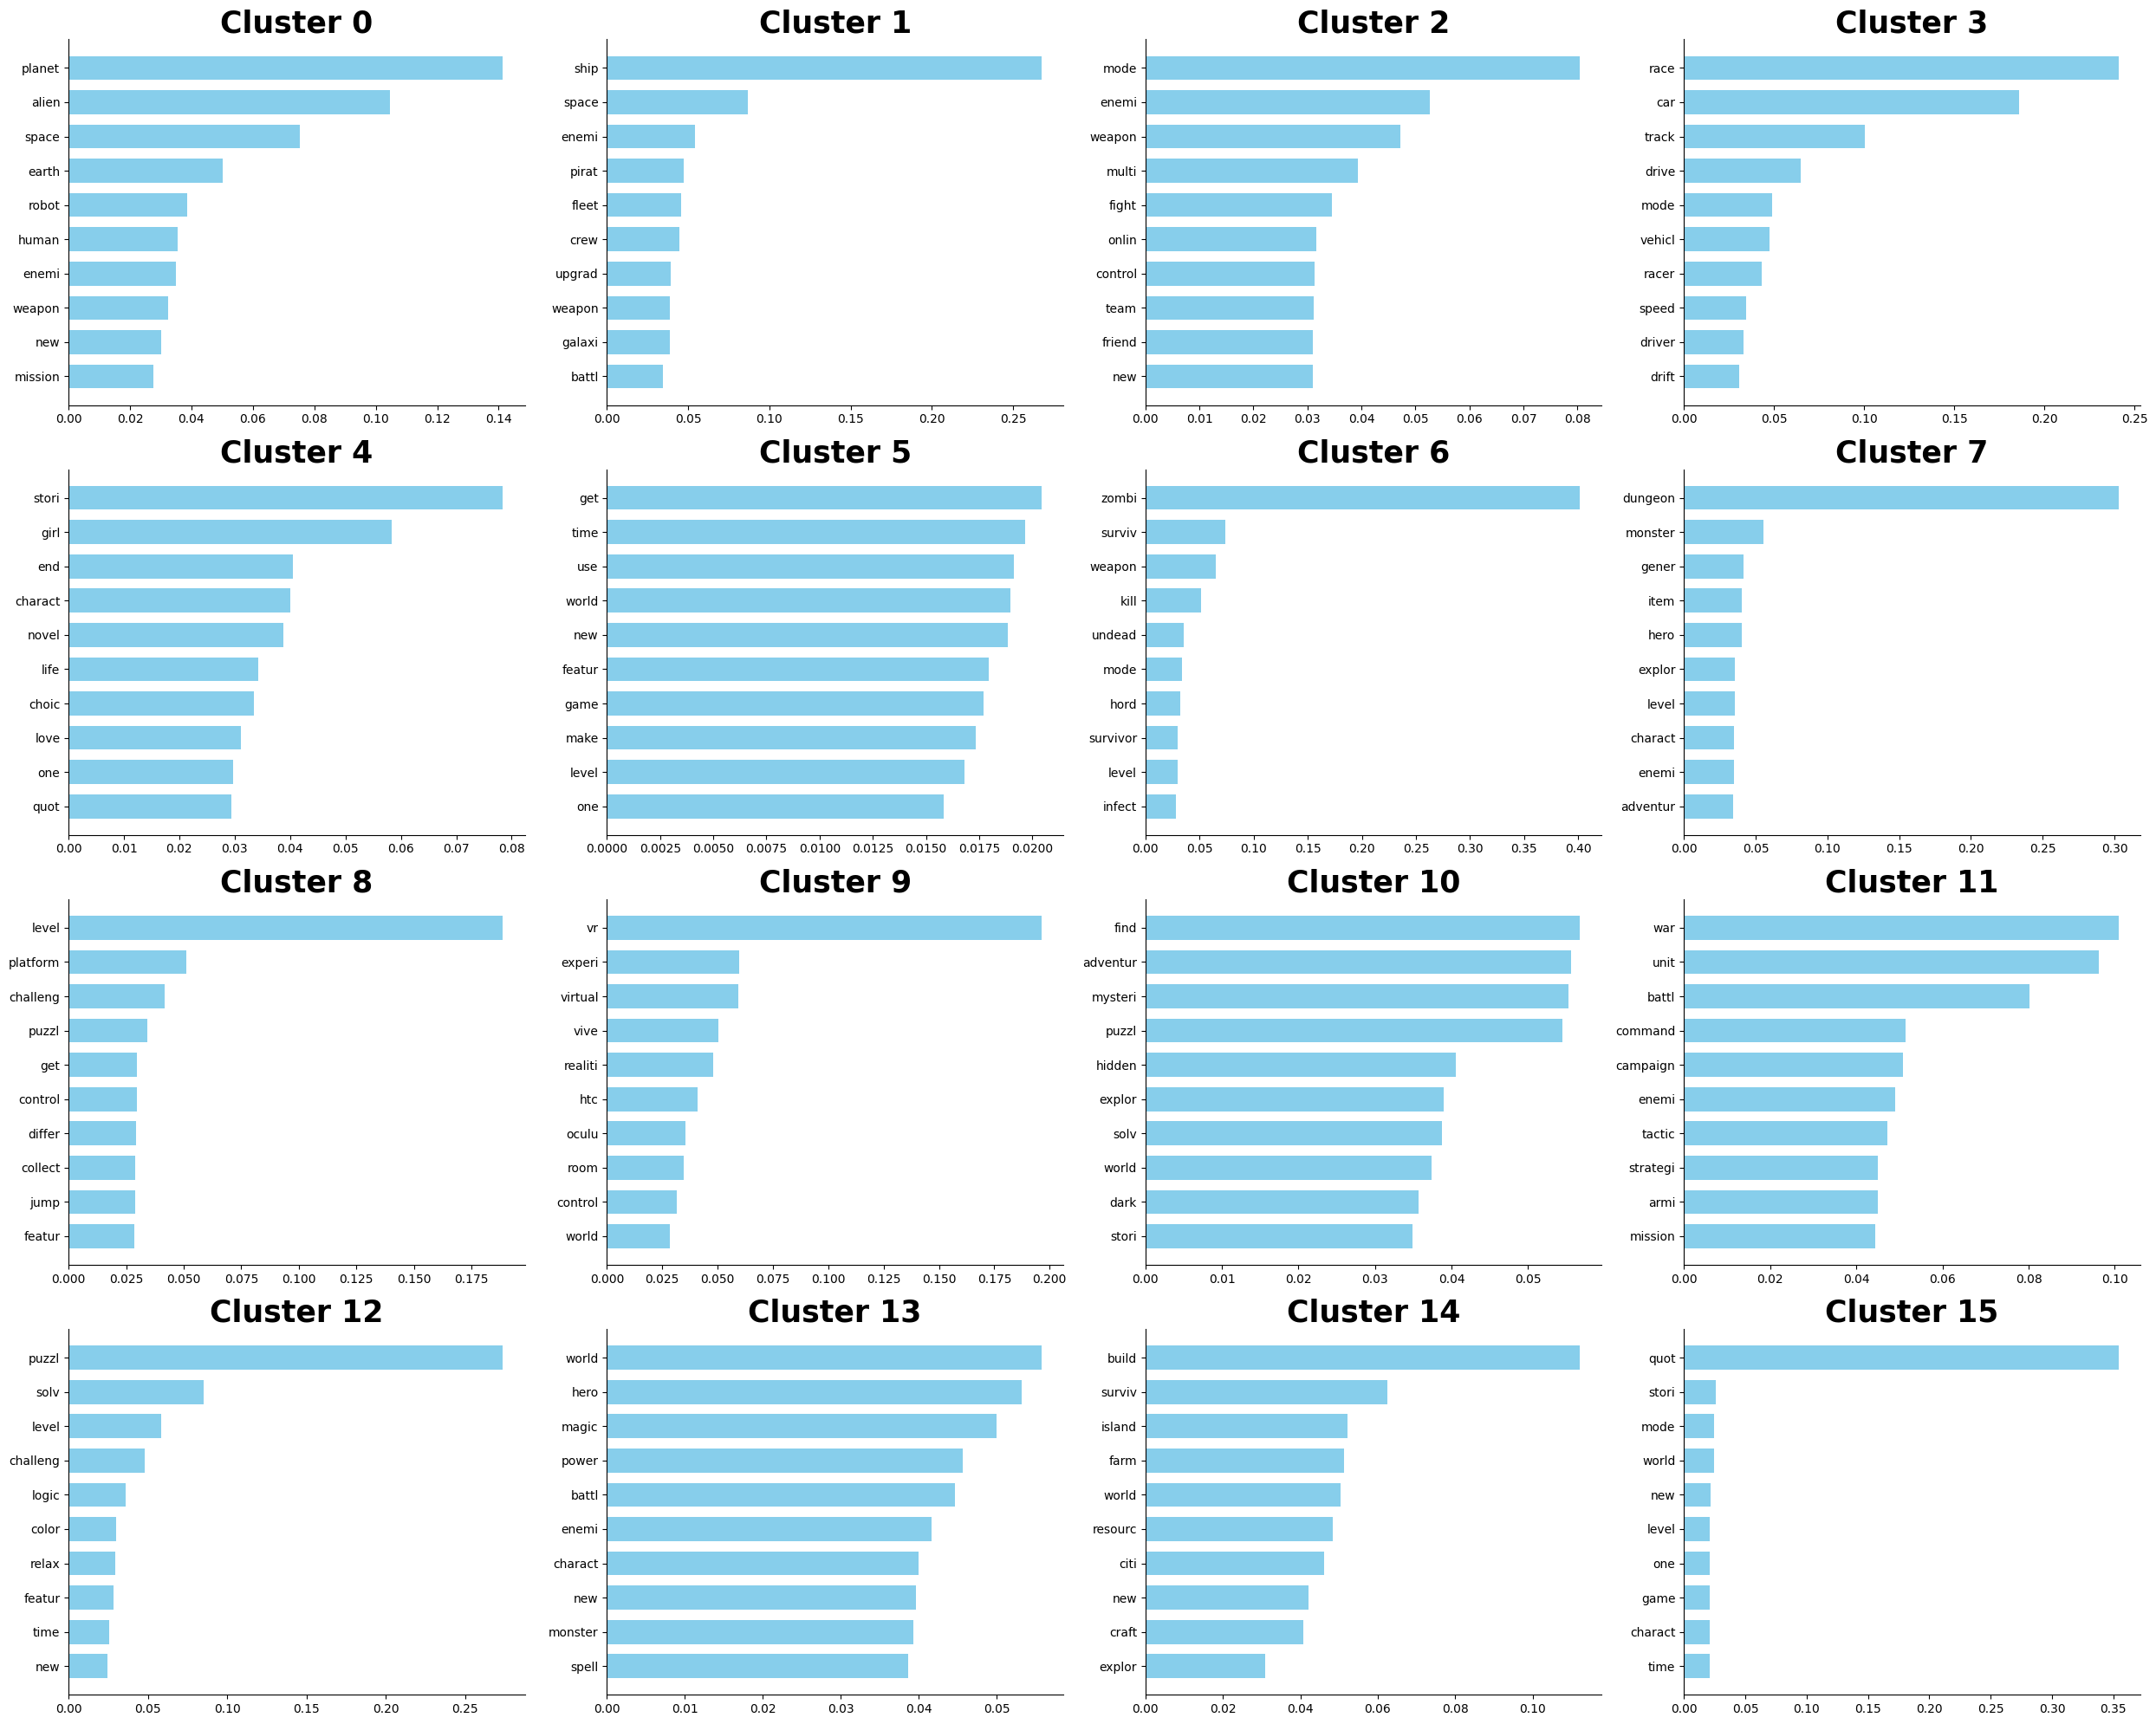

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#mostra grafico de barras com as palavras
def plot_kmeans_top_words(centroids, feature_names, n_top_words=10):
    n_clusters = centroids.shape[0]
   
    rows = 4
    cols = 4
    
    fig, axes = plt.subplots(rows, cols, figsize=(25, 5 * rows), sharex=False)
    axes = axes.flatten()

    for i in range(n_clusters):
        top_indices = centroids[i].argsort()[::-1][:n_top_words]
        top_words = [feature_names[ind] for ind in top_indices]
        top_weights = centroids[i][top_indices]
        
        ax = axes[i]
        # Plotar
        ax.barh(top_words, top_weights, height=0.7, color='skyblue')
        ax.set_title(f"Cluster {i}", fontsize=25, fontweight='bold')
        ax.invert_yaxis() # Palavra mais importante no topo
        ax.tick_params(axis='both', labelsize=10)
        
        # Limpar visual
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Remover subplots vazios se houver
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Chamada da função com seus dados
plot_kmeans_top_words(original_space_centroids, terms)

***terminar issoaq
Com isso, podemos fazer uma associação entre o(s) gênero(s) e as palavras mais importantes da sua descrição...